In [4]:
import pandas as pd

df_dga = pd.read_csv("C:\\Personal\\projects\\lstm_data_set\\dga_data.csv")
print(df_dga.head())
print(df_dga.info())
print(df_dga.describe(include='all'))

  isDGA                      domain                            host  \
0   dga  6xzxsw3sokvg1tc752y1a6p0af  6xzxsw3sokvg1tc752y1a6p0af.com   
1   dga              glbtlxwwhbnpxs               glbtlxwwhbnpxs.ru   
2   dga              xxmamopyipbfpk               xxmamopyipbfpk.ru   
3   dga   zfd5szpi18i85wj9uy13l69rg   zfd5szpi18i85wj9uy13l69rg.net   
4   dga                jpqftymiuver                 jpqftymiuver.ru   

       subclass  
0   gameoverdga  
1  cryptolocker  
2  cryptolocker  
3        newgoz  
4  cryptolocker  
<class 'pandas.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype
---  ------    --------------   -----
 0   isDGA     160000 non-null  str  
 1   domain    159998 non-null  str  
 2   host      160000 non-null  str  
 3   subclass  160000 non-null  str  
dtypes: str(4)
memory usage: 4.9 MB
None
         isDGA                      domain            host subclass
count   160000               

In [5]:
df_dga[df_dga["isDGA"] == "legit"].head()

,isDGA,domain,host,subclass
80000,legit,zige365,zige365.com,legit
80001,legit,sportswiki,sportswiki.ru,legit
80002,legit,clutchfans,clutchfans.net,alexa
80003,legit,meuslinks,meuslinks.com,legit
80004,legit,atskype,atskype.jp,legit


In [6]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df_dga, test_size=0.2, random_state=42, stratify=df_dga["isDGA"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["isDGA"])

print(f"Train: {len(train_df)} ({len(train_df)/len(df_dga)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df_dga)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df_dga)*100:.1f}%)")


Train: 128000 (80.0%)
Val:   16000 (10.0%)
Test:  16000 (10.0%)


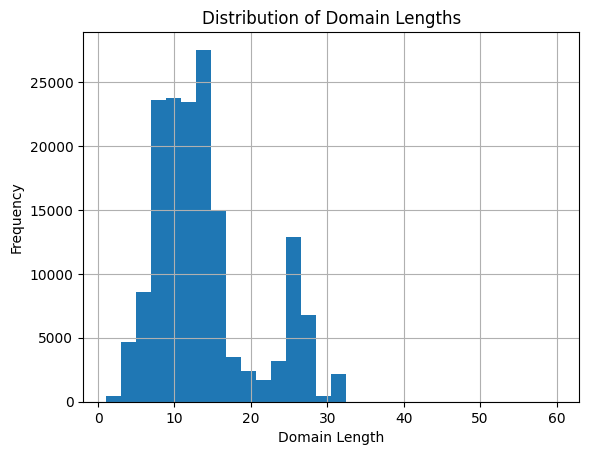

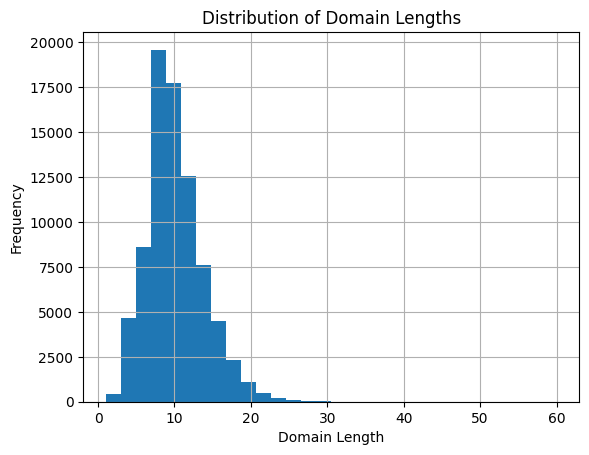

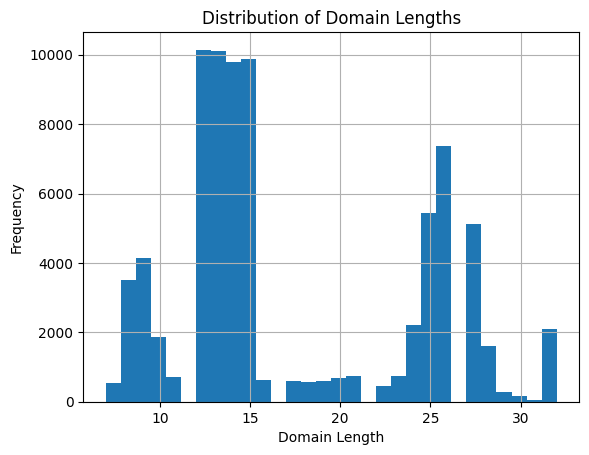

In [7]:
import matplotlib.pyplot as plt
df_dga['domain_len'] = df_dga['domain'].str.len()
df_dga['domain_len'].hist(bins=30)
plt.title('Distribution of Domain Lengths')
plt.xlabel('Domain Length')
plt.ylabel('Frequency')
plt.show()

df_dga['domain_len'] = df_dga[df_dga['isDGA'] == 'legit']['domain'].str.len()
df_dga['domain_len'].hist(bins=30)
plt.title('Distribution of Domain Lengths')
plt.xlabel('Domain Length')
plt.ylabel('Frequency')
plt.show()

df_dga['domain_len'] = df_dga[df_dga['isDGA'] == 'dga']['domain'].str.len()
df_dga['domain_len'].hist(bins=30)
plt.title('Distribution of Domain Lengths')
plt.xlabel('Domain Length')
plt.ylabel('Frequency')
plt.show()

In [13]:
df_dga[df_dga['isDGA'] == 'dga']['subclass'].value_counts()

subclass
cryptolocker    37254
newgoz           9276
gameoverdga      8461
nivdort          8456
necurs           8331
goz              6136
bamital          2086
Name: count, dtype: int64

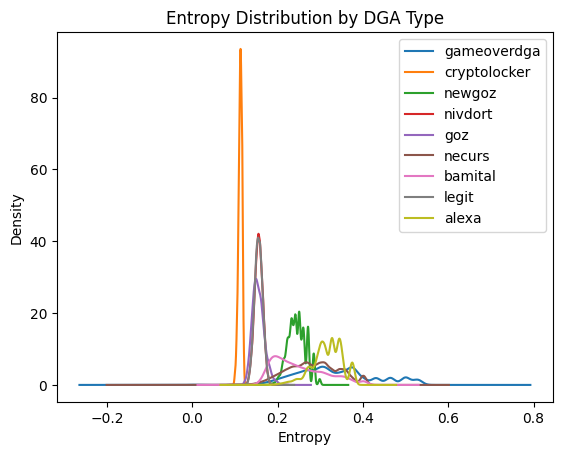

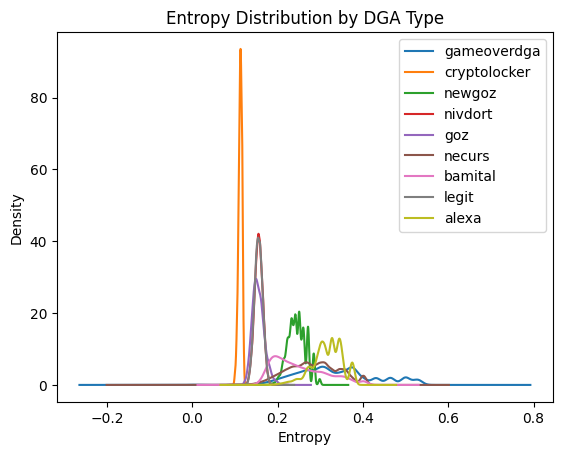

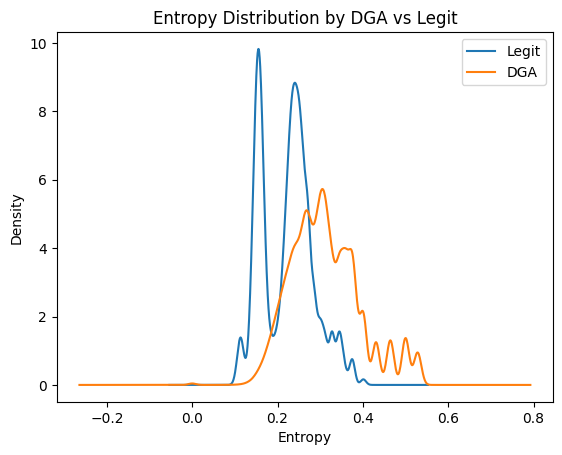

In [21]:
def entropy(s):
    from math import log2
    from collections import Counter
    s = str(s)
    counts = Counter(s)
    total = len(s)
    return (-sum((count / total) * log2(count / total) for count in counts.values()))/total

df_dga['entropy'] = df_dga['domain'].apply(entropy)
df_dga.groupby('subclass')['entropy'].plot.kde()
plt.title('Entropy Distribution by DGA Type')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.legend(df_dga['subclass'].unique())
plt.show()

df_dga['entropy'] = df_dga['domain'].apply(entropy)
df_dga.groupby('isDGA')['entropy'].plot.kde()
plt.title('Entropy Distribution by DGA vs Legit')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.legend(['Legit', 'DGA'])
plt.show()

In [12]:
import string
import torch
from torch.utils.data import Dataset, DataLoader

CharTokens = string.printable
chr2indx = {}
chr2indx["<PAD>"] = 0
chr2indx['<UNK>'] = 1
for i, char in enumerate(CharTokens[:-5], start=2):
    chr2indx[char] = i
indx2chr = {i: char for char, i in chr2indx.items()}

MAX_LEN = 64

def encode_domain(domain, max_len=MAX_LEN):
    d = str(domain).lower()[:max_len]
    encoded = [chr2indx['<PAD>']] * (max_len - len(d))
    encoded += [chr2indx.get(char, chr2indx['<UNK>']) for char in d]
    return encoded

label_map = {'legit': 0, 'dga': 1}
class DGADataset(Dataset):
    def __init__(self, df, max_len):
        self.X = [encode_domain(d, max_len) for d in df['domain']]  # done ONCE
        self.y = [label_map[label] for label in df['isDGA']]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        encoded_domain = self.X[idx]
        label = self.y[idx]
        return torch.tensor(encoded_domain, dtype=torch.float), torch.tensor(label, dtype=torch.float)

train_dataset = DGADataset(train_df, MAX_LEN)
val_dataset = DGADataset(val_df, MAX_LEN)
test_dataset = DGADataset(test_df, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

x0, y0 = next(iter(train_loader))
print("Encoded domain shape:", x0.shape)
print("Label shape:", y0.shape)
print("First encoded domain:", x0[0])
print("First label:", y0[0])


Encoded domain shape: torch.Size([128, 64])
Label shape: torch.Size([128])
First encoded domain: tensor([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 14., 19., 16., 29., 25.,
        26., 24., 26., 29., 76., 30., 27., 13.])
First label: tensor(0.)


In [13]:
from torch import nn
class DGA_LSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=128, output_dim=1, dropout=0.3):
        super(DGA_LSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=chr2indx['<PAD>'])
        self.LSTM = nn.LSTM(embedding_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
        
    def forward(self, x):
        output, _ = self.LSTM(self.embedding(x.long()))
        output = self.fc(output[:, -1, :])
        return output


In [20]:
import numpy as np
criterion = nn.BCEWithLogitsLoss()
model = DGA_LSTM(vocab_size=len(chr2indx))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
def trainModel(epoch = 15, batch_loader = train_loader):
    model.train()
    for ep in range(epoch):
        total_loss = 0
        for x_batch, y_batch in batch_loader:
            optimizer.zero_grad()
            output = model(x_batch.long())
            loss = criterion(output.squeeze().float(), y_batch.float())
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {ep+1}/{epoch}, Loss: {total_loss/len(batch_loader):.4f}")

def testModel(batch_loader = test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x_batch, y_batch in batch_loader:
            preds = torch.sigmoid(model(x_batch.long())).squeeze().round().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    print(f"Test Accuracy: {accuracy:.4f}")
    return accuracy

def evalModel(batch_loader = val_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x_batch, y_batch in batch_loader:
            preds = torch.sigmoid(model(x_batch.long())).squeeze().round().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())
    accuracy = (np.array(all_preds) == np.array(all_labels)).mean()
    print(f"Eval Accuracy: {accuracy:.4f}")

epoch = 15
i = 0
while True:
    trainModel(epoch=epoch)
    accuracy = testModel()
    if accuracy > 0.96 or i > 5:
        break
    else:
        i += 1
        epoch += 5

evalModel()

Epoch 1/15, Loss: 0.1622
Epoch 2/15, Loss: 0.0594
Epoch 3/15, Loss: 0.0361
Epoch 4/15, Loss: 0.0279
Epoch 5/15, Loss: 0.0218
Epoch 6/15, Loss: 0.0184
Epoch 7/15, Loss: 0.0145
Epoch 8/15, Loss: 0.0133
Epoch 9/15, Loss: 0.0106
Epoch 10/15, Loss: 0.0094
Epoch 11/15, Loss: 0.0080
Epoch 12/15, Loss: 0.0076
Epoch 13/15, Loss: 0.0065
Epoch 14/15, Loss: 0.0053
Epoch 15/15, Loss: 0.0047
Test Accuracy: 0.9903
Eval Accuracy: 0.9915
